# Synthetic PCB Dataset Evaluation
Compares the synthetic dataset against the real `pcb-defect-dataset` across distribution, fidelity, diversity, and PCB-specific signal metrics.

In [1]:
# %pip install torchmetrics umap-learn vendi-score scikit-learn prdc imagehash -q

In [2]:
import os, random, warnings
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm
from scipy.stats import wasserstein_distance, ks_2samp
warnings.filterwarnings('ignore')

# ── paths ────────────────────────────────────────────────────────────────────
REAL_DIR = 'datasets/pcb-defect-dataset/train/images'
GEN_DIR  = 'datasets/generated_dataset/defects/images'  # swap when full dataset arrives

# ── config ───────────────────────────────────────────────────────────────────
N     = 3000   # images sampled from real; all gen images used (capped at N)
SEED  = 42
BATCH = 32

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

# torchmetrics FID/KID use InceptionV3 ops not fully supported on MPS
METRIC_DEVICE = 'cpu' if DEVICE == 'mps' else DEVICE

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'device: {DEVICE}  |  metric device: {METRIC_DEVICE}')

device: mps  |  metric device: cpu


## 1. Load image paths

In [3]:
def collect_paths(folder):
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in exts]

all_real = collect_paths(REAL_DIR)
all_gen  = collect_paths(GEN_DIR)

print(f'found — real: {len(all_real)}  gen: {len(all_gen)}')

found — real: 8534  gen: 3000


## 2. Deduplication
- **Real**: perceptual hash (phash) — images of the same PCB patch with different defect placements have near-identical hashes; keep one per unique patch.
- **Gen**: filename prefix — `layout_N_repK.png` → keep one representative per `layout_N`, discard the other reps.

In [4]:
import imagehash

TMP_REAL = 'tmp_dedup/real'
TMP_GEN  = 'tmp_dedup/gen'
os.makedirs(TMP_REAL, exist_ok=True)
os.makedirs(TMP_GEN,  exist_ok=True)

# Hamming distance threshold: ≤ this → near-duplicate. Tune down for stricter dedup.
PHASH_THRESHOLD = 8

def dedup_by_phash(paths, out_dir, threshold):
    kept_paths, kept_hashes = [], []
    for p in tqdm(paths, desc='hashing real'):
        h = imagehash.phash(Image.open(p).convert('RGB'))
        if all(h - kh > threshold for kh in kept_hashes):
            kept_paths.append(p)
            kept_hashes.append(h)
            dst = os.path.join(out_dir, os.path.basename(p))
            if not os.path.lexists(dst):
                os.symlink(os.path.abspath(p), dst)
    return kept_paths

def dedup_gen_by_layout(paths, out_dir):
    seen, kept = set(), []
    for p in sorted(paths):  # sort so _rep0 is always chosen
        layout_id = os.path.basename(p).split('_rep')[0]
        if layout_id not in seen:
            seen.add(layout_id)
            kept.append(p)
            dst = os.path.join(out_dir, os.path.basename(p))
            if not os.path.lexists(dst):
                os.symlink(os.path.abspath(p), dst)
    return kept

print(f'deduplicating real ({len(all_real)} images), phash threshold={PHASH_THRESHOLD}...')
unique_real = dedup_by_phash(all_real, TMP_REAL, PHASH_THRESHOLD)

print(f'deduplicating gen ({len(all_gen)} images) by layout prefix...')
unique_gen = dedup_gen_by_layout(all_gen, TMP_GEN)

real_paths = random.sample(unique_real, min(N, len(unique_real)))
gen_paths  = list(unique_gen[:min(N, len(unique_gen))])

print(f'\nbefore dedup — real: {len(all_real)}   gen: {len(all_gen)}')
print(f'after  dedup — real: {len(unique_real)}  gen: {len(unique_gen)}')
print(f'used for eval — real: {len(real_paths)}  gen: {len(gen_paths)}')

deduplicating real (8534 images), phash threshold=8...


hashing real: 100%|██████████| 8534/8534 [00:11<00:00, 760.18it/s]

deduplicating gen (3000 images) by layout prefix...

before dedup — real: 8534   gen: 3000
after  dedup — real: 164  gen: 500
used for eval — real: 164  gen: 500


## 2. Feature extraction (DenseNet121)

In [5]:
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

embed_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert('RGB'))

backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
backbone = torch.nn.Sequential(
    backbone.features,
    torch.nn.AdaptiveAvgPool2d((1, 1)),
    torch.nn.Flatten()
).to(DEVICE).eval()

def extract_embeddings(paths):
    # num_workers=0: macOS Jupyter uses spawn, not fork — workers > 0 hang
    loader = DataLoader(PathDataset(paths, embed_transform), batch_size=BATCH, num_workers=0)
    parts = []
    with torch.no_grad():
        for batch in tqdm(loader):
            parts.append(backbone(batch.to(DEVICE)).cpu().numpy())
    return np.vstack(parts)

print('extracting real embeddings...')
real_emb = extract_embeddings(real_paths)
print('extracting gen embeddings...')
gen_emb  = extract_embeddings(gen_paths)
print(f'embedding shapes — real: {real_emb.shape}  gen: {gen_emb.shape}')

extracting real embeddings...


100%|██████████| 6/6 [00:01<00:00,  3.50it/s]


extracting gen embeddings...


100%|██████████| 16/16 [00:06<00:00,  2.47it/s]

embedding shapes — real: (164, 1024)  gen: (500, 1024)


In [6]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from vendi_score import vendi

fid_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

def load_uint8_tensors(paths):
    # num_workers=0: macOS Jupyter uses spawn, not fork — workers > 0 hang
    loader = DataLoader(PathDataset(paths, fid_transform), batch_size=BATCH, num_workers=0)
    parts = []
    for batch in tqdm(loader):
        parts.append((batch * 255).to(torch.uint8))
    return torch.cat(parts)

print('loading uint8 tensors for FID/KID...')
real_u8 = load_uint8_tensors(real_paths)
gen_u8  = load_uint8_tensors(gen_paths)

loading uint8 tensors for FID/KID...


100%|██████████| 16/16 [00:02<00:00,  5.44it/s]


In [7]:
def compute_fid(real_t, gen_t):
    metric = FrechetInceptionDistance(feature=2048).to(METRIC_DEVICE)
    for i in tqdm(range(0, len(real_t), BATCH)):
        metric.update(real_t[i:i+BATCH].to(METRIC_DEVICE), real=True)
    for i in tqdm(range(0, len(gen_t), BATCH)):
        metric.update(gen_t[i:i+BATCH].to(METRIC_DEVICE), real=False)
    return metric.compute().item()

def compute_kid(real_t, gen_t):
    # subset_size must be strictly less than both real and fake sample counts
    subset_size = min(1000, len(real_t), len(gen_t)) - 1
    metric = KernelInceptionDistance(feature=2048, subset_size=subset_size).to(METRIC_DEVICE)
    for i in tqdm(range(0, len(real_t), BATCH)):
        metric.update(real_t[i:i+BATCH].to(METRIC_DEVICE), real=True)
    for i in tqdm(range(0, len(gen_t), BATCH)):
        metric.update(gen_t[i:i+BATCH].to(METRIC_DEVICE), real=False)
    mean, std = metric.compute()
    return mean.item(), std.item()

print('computing FID (gen vs real)...')
fid_gen = compute_fid(real_u8, gen_u8)

# real-vs-real baseline: split real in half
mid = len(real_u8) // 2
print('computing FID baseline (real-A vs real-B)...')
fid_base = compute_fid(real_u8[:mid], real_u8[mid:])

print('computing KID...')
kid_mean, kid_std = compute_kid(real_u8, gen_u8)

print('computing Vendi scores...')
vendi_real = vendi.score_X(real_emb)
vendi_gen  = vendi.score_X(gen_emb)

print(f'\nFID  gen vs real : {fid_gen:.2f}')
print(f'FID  baseline    : {fid_base:.2f}')
print(f'KID              : {kid_mean:.4f} ± {kid_std:.4f}')
print(f'Vendi real       : {vendi_real:.2f}')
print(f'Vendi gen        : {vendi_gen:.2f}')

computing FID (gen vs real)...


100%|██████████| 16/16 [00:49<00:00,  3.11s/it]


computing FID baseline (real-A vs real-B)...


100%|██████████| 3/3 [00:08<00:00,  2.81s/it]


computing KID...


100%|██████████| 16/16 [00:51<00:00,  3.23s/it]

computing Vendi scores...

FID  gen vs real : 295.07
FID  baseline    : 48.63
KID              : 0.4131 ± 0.0071
Vendi real       : 5.89
Vendi gen        : 2.14


## 4. Precision, Recall, Density, Coverage

In [8]:
from prdc import compute_prdc

prdc_metrics = compute_prdc(
    real_features=real_emb,
    fake_features=gen_emb,
    nearest_k=5
)

print('Precision (fidelity) :', round(prdc_metrics['precision'], 4))
print('Recall    (coverage)  :', round(prdc_metrics['recall'],    4))
print('Density               :', round(prdc_metrics['density'],   4))
print('Coverage              :', round(prdc_metrics['coverage'],  4))

Num real: 164 Num fake: 500
Precision (fidelity) : 0.004
Recall    (coverage)  : 0.0
Density               : 0.0008
Coverage              : 0.0122


## 5. UMAP overlay

fitting UMAP...


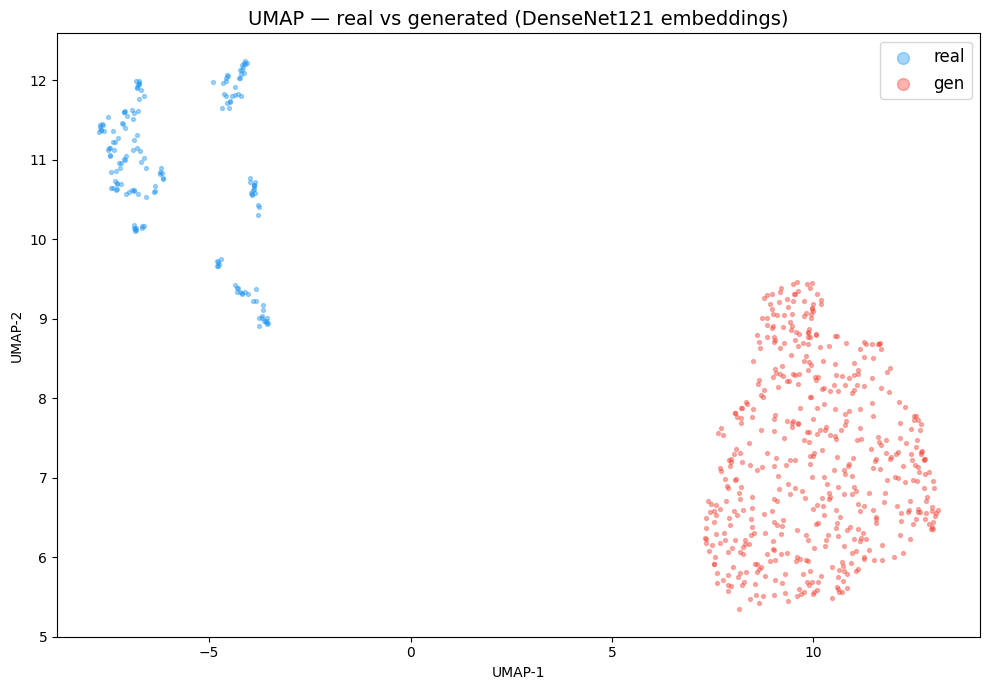

In [9]:
import umap

combined = np.vstack([real_emb, gen_emb])
labels   = np.array(['real'] * len(real_emb) + ['gen'] * len(gen_emb))

print('fitting UMAP...')
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
proj    = reducer.fit_transform(combined)

fig, ax = plt.subplots(figsize=(10, 7))
for label, color in [('real', '#2196F3'), ('gen', '#F44336')]:
    mask = labels == label
    ax.scatter(proj[mask, 0], proj[mask, 1],
               c=color, alpha=0.4, s=8, label=label)
ax.set_title('UMAP — real vs generated (DenseNet121 embeddings)', fontsize=14)
ax.legend(markerscale=3, fontsize=12)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.show()

## 6. PCB-domain metrics

### 6a. Color histograms (LAB space) + Wasserstein distance

sampling color histograms...


100%|██████████| 500/500 [00:05<00:00, 93.08it/s]


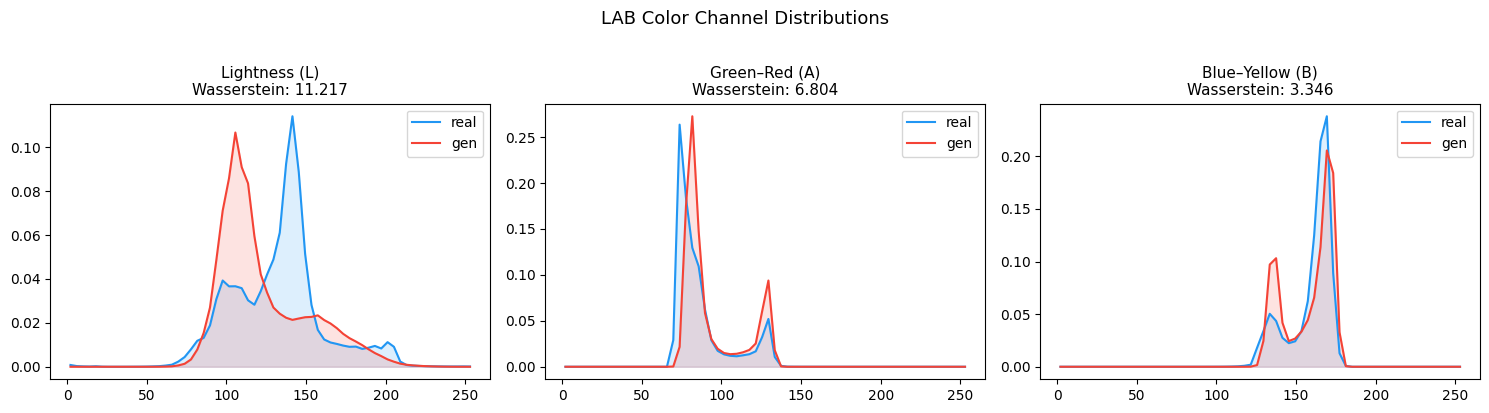

Wasserstein distances: {'L': np.float64(11.2171), 'A': np.float64(6.8037), 'B': np.float64(3.3456)}


In [10]:
def sample_lab_histograms(paths, n_sample=500, bins=64):
    """Returns per-channel histogram arrays (L, A, B)."""
    hists = {c: np.zeros(bins) for c in ('L', 'A', 'B')}
    sampled = random.sample(paths, min(n_sample, len(paths)))
    for p in tqdm(sampled):
        img = cv2.imread(p)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
        for ci, ch in enumerate(('L', 'A', 'B')):
            h, _ = np.histogram(lab[:, :, ci].ravel(), bins=bins, range=(0, 255))
            hists[ch] += h
    # normalize
    for ch in hists:
        hists[ch] = hists[ch] / hists[ch].sum()
    return hists

print('sampling color histograms...')
real_hists = sample_lab_histograms(real_paths)
gen_hists  = sample_lab_histograms(gen_paths)

bins = np.linspace(0, 255, 65)
centers = (bins[:-1] + bins[1:]) / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = {'L': 'Lightness (L)', 'A': 'Green–Red (A)', 'B': 'Blue–Yellow (B)'}
wass = {}
for ax, ch in zip(axes, ('L', 'A', 'B')):
    ax.plot(centers, real_hists[ch], label='real',  color='#2196F3', linewidth=1.5)
    ax.plot(centers, gen_hists[ch],  label='gen',   color='#F44336', linewidth=1.5)
    ax.fill_between(centers, real_hists[ch], alpha=0.15, color='#2196F3')
    ax.fill_between(centers, gen_hists[ch],  alpha=0.15, color='#F44336')
    w = wasserstein_distance(centers, centers, real_hists[ch], gen_hists[ch])
    wass[ch] = w
    ax.set_title(f'{channel_names[ch]}\nWasserstein: {w:.3f}', fontsize=11)
    ax.legend()
plt.suptitle('LAB Color Channel Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Wasserstein distances:', {k: round(v, 4) for k, v in wass.items()})

### 6b. Gradient magnitude distribution

computing gradient magnitudes...


100%|██████████| 500/500 [00:02<00:00, 177.52it/s]


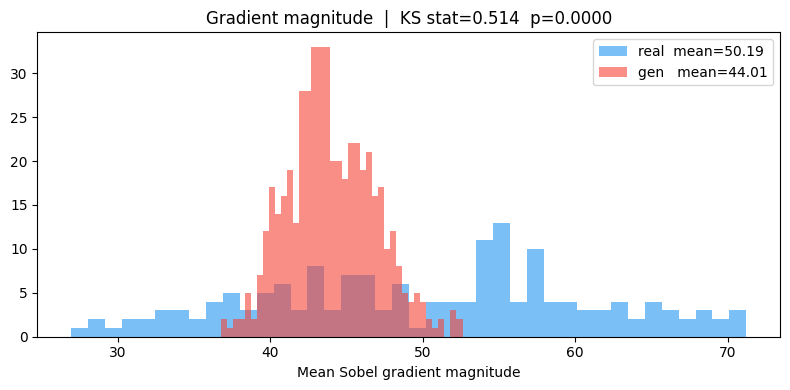

In [11]:
def gradient_magnitudes(paths, n_sample=500):
    mags = []
    sampled = random.sample(paths, min(n_sample, len(paths)))
    for p in tqdm(sampled):
        img  = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        gx   = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        gy   = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        mags.append(np.mean(np.sqrt(gx**2 + gy**2)))
    return np.array(mags)

print('computing gradient magnitudes...')
real_grads = gradient_magnitudes(real_paths)
gen_grads  = gradient_magnitudes(gen_paths)

ks_stat, ks_p = ks_2samp(real_grads, gen_grads)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_grads, bins=40, alpha=0.6, color='#2196F3', label=f'real  mean={real_grads.mean():.2f}')
ax.hist(gen_grads,  bins=40, alpha=0.6, color='#F44336', label=f'gen   mean={gen_grads.mean():.2f}')
ax.set_title(f'Gradient magnitude  |  KS stat={ks_stat:.3f}  p={ks_p:.4f}', fontsize=12)
ax.set_xlabel('Mean Sobel gradient magnitude')
ax.legend()
plt.tight_layout()
plt.show()

### 6c. FFT power spectrum

computing FFT power spectra...


100%|██████████| 200/200 [00:01<00:00, 118.89it/s]


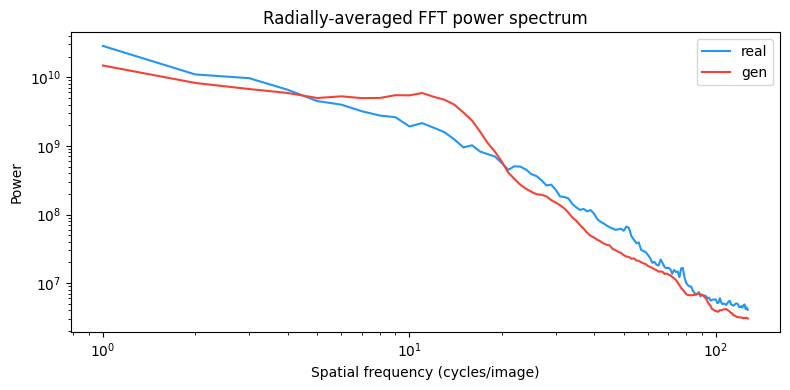

In [12]:
def radial_power_spectrum(paths, n_sample=200, size=256):
    """Radially-averaged 1D power spectrum averaged over n_sample images."""
    half = size // 2
    # radial bin indices
    y, x = np.indices((size, size)) - half
    r = np.sqrt(x**2 + y**2).astype(int)
    r_max = half

    power_sum = np.zeros(r_max)
    sampled = random.sample(paths, min(n_sample, len(paths)))
    for p in tqdm(sampled):
        img  = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        img  = cv2.resize(img, (size, size)).astype(np.float32)
        fft  = np.fft.fftshift(np.fft.fft2(img))
        mag  = np.abs(fft) ** 2
        for ri in range(r_max):
            mask = r == ri
            if mask.any():
                power_sum[ri] += mag[mask].mean()
    return power_sum / len(sampled)

print('computing FFT power spectra...')
real_ps = radial_power_spectrum(real_paths)
gen_ps  = radial_power_spectrum(gen_paths)

freqs = np.arange(1, len(real_ps))
fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(freqs, real_ps[1:], color='#2196F3', linewidth=1.5, label='real')
ax.loglog(freqs, gen_ps[1:],  color='#F44336', linewidth=1.5, label='gen')
ax.set_title('Radially-averaged FFT power spectrum', fontsize=12)
ax.set_xlabel('Spatial frequency (cycles/image)')
ax.set_ylabel('Power')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Summary

In [13]:
from IPython.display import Markdown, display

rows = [
    ('FID (gen vs real)',     f'{fid_gen:.2f}',                   f'baseline real-vs-real: {fid_base:.2f}'),
    ('KID',                   f'{kid_mean:.4f} ± {kid_std:.4f}',  'lower is better'),
    ('Vendi Score — real',    f'{vendi_real:.2f}',                'effective # of distinct images'),
    ('Vendi Score — gen',     f'{vendi_gen:.2f}',                 ''),
    ('Precision',             f"{prdc_metrics['precision']:.4f}", '% gen in real manifold (fidelity)'),
    ('Recall',                f"{prdc_metrics['recall']:.4f}",    '% real covered by gen (diversity)'),
    ('Density',               f"{prdc_metrics['density']:.4f}",   ''),
    ('Coverage',              f"{prdc_metrics['coverage']:.4f}",  ''),
    ('Wasserstein L',         f"{wass['L']:.4f}",                 'LAB lightness channel'),
    ('Wasserstein A',         f"{wass['A']:.4f}",                 'LAB green–red channel'),
    ('Wasserstein B',         f"{wass['B']:.4f}",                 'LAB blue–yellow channel'),
    ('Grad mag mean — real',  f'{real_grads.mean():.2f}',         'Sobel texture complexity'),
    ('Grad mag mean — gen',   f'{gen_grads.mean():.2f}',          ''),
    ('KS stat (grad mag)',    f'{ks_stat:.4f}',                   f'p={ks_p:.4f}'),
]

header = '| Metric | Value | Notes |\n|---|---|---|\n'
body   = '\n'.join(f'| {m} | {v} | {n} |' for m, v, n in rows)
display(Markdown(header + body))

| Metric | Value | Notes |
|---|---|---|
| FID (gen vs real) | 295.07 | baseline real-vs-real: 48.63 |
| KID | 0.4131 ± 0.0071 | lower is better |
| Vendi Score — real | 5.89 | effective # of distinct images |
| Vendi Score — gen | 2.14 |  |
| Precision | 0.0040 | % gen in real manifold (fidelity) |
| Recall | 0.0000 | % real covered by gen (diversity) |
| Density | 0.0008 |  |
| Coverage | 0.0122 |  |
| Wasserstein L | 11.2171 | LAB lightness channel |
| Wasserstein A | 6.8037 | LAB green–red channel |
| Wasserstein B | 3.3456 | LAB blue–yellow channel |
| Grad mag mean — real | 50.19 | Sobel texture complexity |
| Grad mag mean — gen | 44.01 |  |
| KS stat (grad mag) | 0.5145 | p=0.0000 |